In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [2]:
# Load only the columns needed for filtering and EDA
columns_needed = ['Product', 'Consumer complaint narrative', 'Complaint ID',
                  'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State',
                  'ZIP code', 'Date received']

df = pd.read_csv('../data/raw/consumer_complaints.csv', 
                 usecols=columns_needed, 
                 low_memory=False)
print(f'Full dataset shape: {df.shape}')
df.head(2)

Full dataset shape: (9609797, 10)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company,State,ZIP code,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Experian Information Solutions Inc.,FL,32092,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,14195688


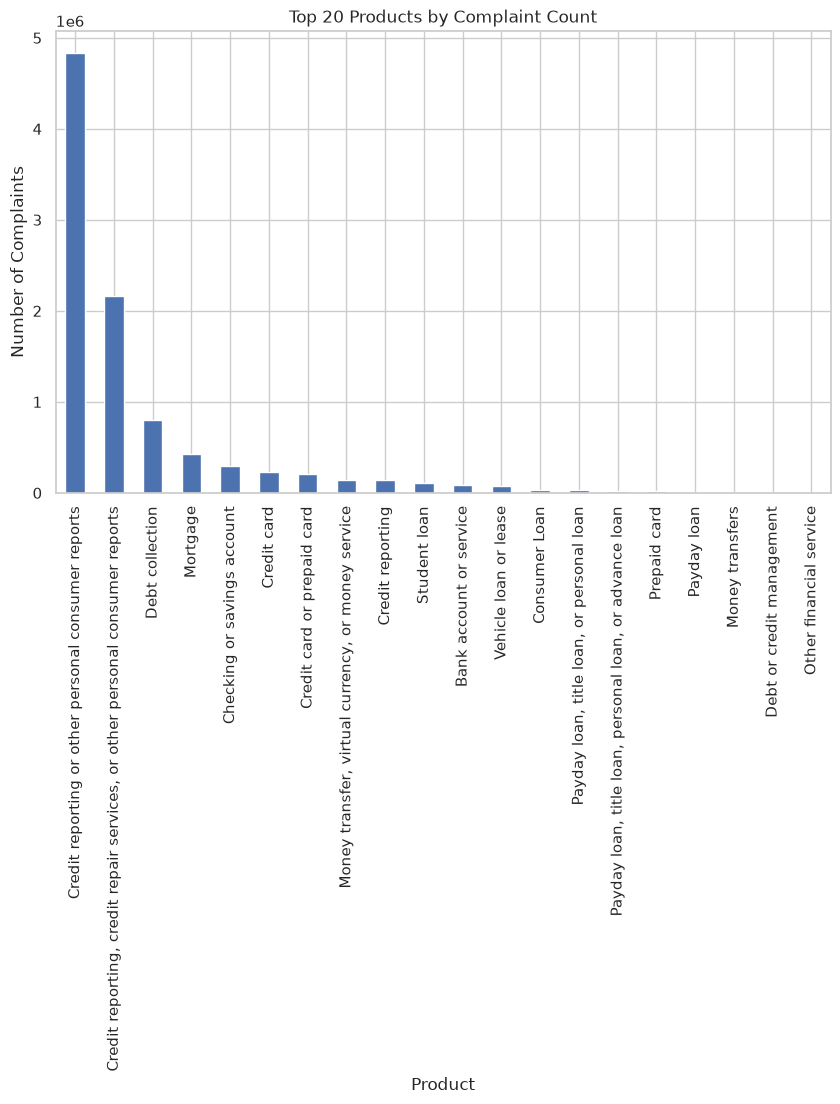

In [9]:
# All products
plt.figure(figsize=(10,6))
df['Product'].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Products by Complaint Count')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.savefig('../reports/images/product_distribution.png', dpi=150)
plt.show()

Narrative length stats:
count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: narrative_length, dtype: float64


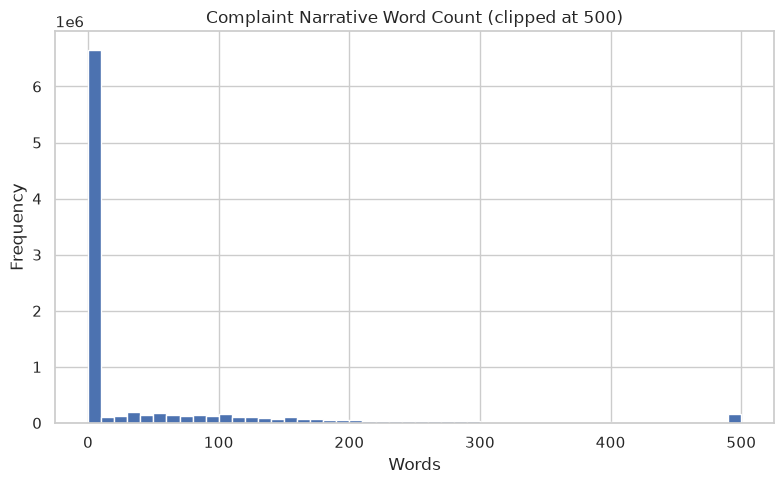

In [10]:
# Add word count column
df['narrative_length'] = df['Consumer complaint narrative'].fillna('').apply(lambda x: len(str(x).split()))
print('Narrative length stats:')
print(df['narrative_length'].describe())

# Plot
plt.figure(figsize=(8,5))
df['narrative_length'].clip(0, 500).hist(bins=50)
plt.title('Complaint Narrative Word Count (clipped at 500)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../reports/images/narrative_length.png', dpi=150)
plt.show()

In [5]:
total = len(df)
has_narrative = df['Consumer complaint narrative'].notna().sum()
missing_narrative = total - has_narrative
print(f'Total complaints: {total}')
print(f'With narrative: {has_narrative} ({has_narrative/total*100:.1f}%)')
print(f'Without narrative: {missing_narrative} ({missing_narrative/total*100:.1f}%)')

Total complaints: 9609797
With narrative: 2980756 (31.0%)
Without narrative: 6629041 (69.0%)


In [6]:
# List of target products (match the dataset's exact spelling)
products = ['Credit card', 'Personal loan', 'Savings account', 'Money transfer']

# Filter
df_filtered = df[df['Product'].isin(products)].copy()
print(f'After product filter: {len(df_filtered)} records')

# Remove rows with missing narratives
df_filtered = df_filtered[df_filtered['Consumer complaint narrative'].notna()].copy()
print(f'After removing empty narratives: {len(df_filtered)} records')

# Check product distribution
print(df_filtered['Product'].value_counts())

After product filter: 226686 records
After removing empty narratives: 80667 records
Product
Credit card    80667
Name: count, dtype: int64


In [7]:
# Lowercase
df_filtered['narrative'] = df_filtered['Consumer complaint narrative'].str.lower()

# Remove special characters (keep letters, numbers, spaces)
df_filtered['narrative'] = df_filtered['narrative'].str.replace(r'[^a-z0-9\s]', ' ', regex=True)

# Remove extra whitespace
df_filtered['narrative'] = df_filtered['narrative'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Remove redacted information (XXXX or XX or XXXX-XXXX patterns)
df_filtered['narrative'] = df_filtered['narrative'].str.replace(r'\b(x{2,})\b', '', regex=True)

# View a sample
print(df_filtered['narrative'].iloc[0][:300])

a   card was opened under my name by a fraudster i received a notice from  that an account was just opened under my name i reached out to   to state that this activity was unauthorized and not me   confirmed this was fraudulent and immediately closed the card however they have failed to remove this 


In [8]:
# Keep relevant columns
columns_to_keep = ['Complaint ID', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
                   'Company', 'State', 'ZIP code', 'Date received', 'narrative']
df_clean = df_filtered[columns_to_keep].copy()

# Save
df_clean.to_csv('../data/processed/filtered_complaints.csv', index=False)
print(f'Saved {len(df_clean)} cleaned records to data/processed/filtered_complaints.csv')

Saved 80667 cleaned records to data/processed/filtered_complaints.csv
